# **Custom CNN**

In [ ]:
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from torchvision import transforms, datasets
import torchvision.models as models
torch.manual_seed(42)

In [ ]:
# install optuna for hyperparameter tuning
!pip install optuna -q
import optuna
from optuna.trial import TrialState


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.7 MB/s eta 0:00:00


In [ ]:
!pip install -q mlflow

import mlflow
import mlflow.pytorch

mlflow.set_tracking_uri("sqlite:///content/mlflow.db")
mlflow.set_experiment("Brain_Cancer_MRI_CustomCNN")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.1/

2026/07/21 15:39:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/21 15:39:32 INFO mlflow.store.db.utils: Updating database tables
2026/07/21 15:39:34 INFO mlflow.tracking.fluent: Experiment with name 'Brain_Cancer_MRI_CustomCNN' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1784648374542, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784648374542, lifecycle_stage='active', name='Brain_Cancer_MRI_CustomCNN', tags={}, trace_location=None, workspace='default'>

In [ ]:
#cheaking cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [ ]:
#base path and resolve path
downloaded_path = kagglehub.dataset_download("orvile/brain-cancer-mri-dataset")
resolved_paths = glob.glob(os.path.join(downloaded_path, '**/Brain_Cancer'), recursive=True)
base_path = resolved_paths[0] if resolved_paths else downloaded_path


Using Colab cache for faster access to the 'brain-cancer-mri-dataset' dataset.


In [ ]:
#catagoris cheaking
categories = ['brain_glioma', 'brain_menin', 'brain_tumor']
num_classes = len(categories)

In [ ]:
full_image_path_list = []
labels = []

for cls in categories:
    cls_path = os.path.join(base_path, cls)
    for img_name in os.listdir(cls_path):
        full_image_path_list.append(os.path.join(cls_path, img_name))
        labels.append(cls)

df = pd.DataFrame({
    'image': full_image_path_list,
    'label': labels
})

print(df)

                                                  image         label
0     /kaggle/input/brain-cancer-mri-dataset/Brain_C...  brain_glioma
1     /kaggle/input/brain-cancer-mri-dataset/Brain_C...  brain_glioma
2     /kaggle/input/brain-cancer-mri-dataset/Brain_C...  brain_glioma
3     /kaggle/input/brain-cancer-mri-dataset/Brain_C...  brain_glioma
4     /kaggle/input/brain-cancer-mri-dataset/Brain_C...  brain_glioma
...                                                 ...           ...
6051  /kaggle/input/brain-cancer-mri-dataset/Brain_C...   brain_tumor
6052  /kaggle/input/brain-cancer-mri-dataset/Brain_C...   brain_tumor
6053  /kaggle/input/brain-cancer-mri-dataset/Brain_C...   brain_tumor
6054  /kaggle/input/brain-cancer-mri-dataset/Brain_C...   brain_tumor
6055  /kaggle/input/brain-cancer-mri-dataset/Brain_C...   brain_tumor

[6056 rows x 2 columns]


In [ ]:
# catagoris cheaking using tolist
df['label_id'], uniques = pd.factorize(df['label'])
num_classes = len(uniques)
print("Class Names:", uniques.tolist())

Class Names: ['brain_glioma', 'brain_menin', 'brain_tumor']


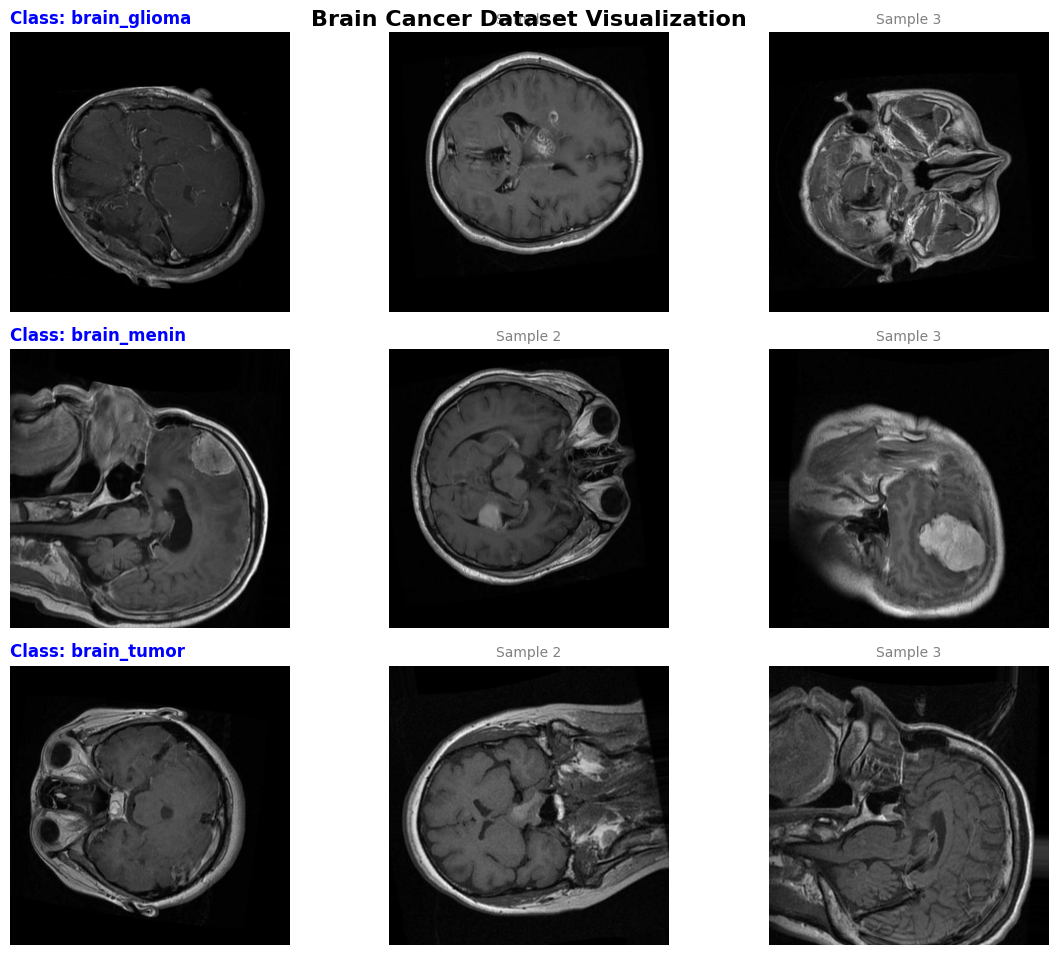

In [ ]:
#show data sets
import random
import matplotlib.pyplot as plt
full_dataset = datasets.ImageFolder(root=base_path)

images_per_class = 3
classes = ['brain_glioma', 'brain_menin', 'brain_tumor']

fig, axes = plt.subplots(len(classes), images_per_class, figsize=(12, 10))
fig.suptitle('Brain Cancer Dataset Visualization', fontsize=16, fontweight='bold', y=0.95)

samples = full_dataset.samples
class_to_idx = full_dataset.class_to_idx

for class_idx, class_name in enumerate(classes):
    target_idx = class_to_idx[class_name]
    class_samples = [path for path, idx in samples if idx == target_idx]
    selected_images = random.sample(class_samples, images_per_class)

    for img_idx, img_path in enumerate(selected_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = axes[class_idx, img_idx]
        ax.imshow(img)
        ax.axis('off')

        if img_idx == 0:
            ax.set_title(f"Class: {class_name}", fontsize=12, loc='left', color='blue', fontweight='bold')
        else:
            ax.set_title(f"Sample {img_idx+1}", fontsize=10, color='gray')

plt.tight_layout()
plt.show()

In [ ]:
# data transformtion
#data transfroms and loaders
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#data splitting
full_dataset = datasets.ImageFolder(root=base_path)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset_full, test_dataset_full = torch.utils.data.random_split(full_dataset, [train_size, test_size])


In [ ]:
# subset
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


#

In [ ]:
#pytorch data loader apply
train_dataset = TransformedSubset(train_dataset_full, transform=train_transforms)
test_dataset = TransformedSubset(test_dataset_full, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 4844
Test size: 1212


In [ ]:
#custom data set create
class EnhancedCNN(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.4):
        super().__init__()
        self.features = nn.Sequential(
            # layer1
            nn.Conv2d(3, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            # layer2
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            # layer3
            nn.Conv2d(128, 256, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),

            # layer4
            nn.Conv2d(256, 512, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Hyperparameter Tuning with Optuna (Custom CNN)

We use Optuna to search over the learning rate, weight decay, dropout rate, batch size, and optimizer type for the `EnhancedCNN` model. Each trial trains a fresh model for a few epochs on a validation split and reports the best validation loss achieved; Optuna also prunes clearly unpromising trials early to save time.

In [ ]:
def objective(trial):
    # --- search space ---
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    optimizer_name = trial.suggest_categorical("optimizer_name", ["Adam", "AdamW", "RMSprop"])

    # data loaders sized to this trial's batch size
    trial_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    trial_val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model = EnhancedCNN(num_classes=num_classes, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    n_epochs = 5  # short training budget per trial to keep the search fast
    best_trial_val_loss = float("inf")

    # each Optuna trial gets its own nested MLflow run, grouped under the parent search run
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        mlflow.log_params({
            "lr": lr,
            "weight_decay": weight_decay,
            "dropout_rate": dropout_rate,
            "batch_size": batch_size,
            "optimizer_name": optimizer_name,
        })

        for epoch in range(n_epochs):
            model.train()
            for batch_features, batch_labels in trial_train_loader:
                batch_features = batch_features.to(device)
                batch_labels = batch_labels.to(device)

                optimizer.zero_grad()
                outputs = model(batch_features)
                loss = criterion(outputs, batch_labels)
                loss.backward()
                optimizer.step()

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch_features, batch_labels in trial_val_loader:
                    batch_features = batch_features.to(device)
                    batch_labels = batch_labels.to(device)
                    outputs = model(batch_features)
                    loss = criterion(outputs, batch_labels)
                    val_loss += loss.item()
            val_loss /= len(trial_val_loader)
            best_trial_val_loss = min(best_trial_val_loss, val_loss)

            mlflow.log_metric("val_loss", val_loss, step=epoch)

            # report intermediate value for pruning
            trial.report(val_loss, epoch)
            if trial.should_prune():
                mlflow.set_tag("pruned", "true")
                raise optuna.exceptions.TrialPruned()

        mlflow.log_metric("best_val_loss", best_trial_val_loss)

    return best_trial_val_loss


In [ ]:
study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())

with mlflow.start_run(run_name="optuna_search_parent") as parent_run:
    study.optimize(objective, n_trials=20)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

print("Study statistics:")
print("  Number of finished trials:", len(study.trials))
print("  Number of pruned trials:", len(pruned_trials))
print("  Number of complete trials:", len(complete_trials))

best_trial = study.best_trial
print("\nBest trial:")
print(f"  Validation loss: {best_trial.value:.4f}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")


[I 2026-07-21 15:39:48,601] A new study created in memory with name: no-name-af5f1b3a-50dd-427d-97c6-6bd59d5d7edf
[I 2026-07-21 15:42:34,003] Trial 0 finished with value: 0.6374920151735607 and parameters: {'lr': 0.0006907144906035136, 'weight_decay': 5.702534615669981e-05, 'dropout_rate': 0.3878597948059481, 'batch_size': 32, 'optimizer_name': 'RMSprop'}. Best is trial 0 with value: 0.6374920151735607.
[I 2026-07-21 15:44:46,952] Trial 1 finished with value: 0.43157513047519486 and parameters: {'lr': 3.139849797507226e-05, 'weight_decay': 8.056149700226439e-05, 'dropout_rate': 0.21462640776920294, 'batch_size': 64, 'optimizer_name': 'AdamW'}. Best is trial 1 with value: 0.43157513047519486.
[I 2026-07-21 15:47:00,442] Trial 2 finished with value: 0.4584651879574123 and parameters: {'lr': 7.951626691128805e-05, 'weight_decay': 0.00013710694036579097, 'dropout_rate': 0.5749286647005596, 'batch_size': 32, 'optimizer_name': 'AdamW'}. Best is trial 1 with value: 0.43157513047519486.
[I 202

Study statistics:
  Number of finished trials: 20
  Number of pruned trials: 7
  Number of complete trials: 13

Best trial:
  Validation loss: 0.3999
  Params:
    lr: 0.00013046894769034697
    weight_decay: 0.00022601999559170453
    dropout_rate: 0.20678048747251285
    batch_size: 64
    optimizer_name: AdamW


In [ ]:
# visualize the optimization results
import optuna.visualization as vis

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()


In [ ]:
# model declaration and parameters using the best hyperparameters found by Optuna
best_params = study.best_trial.params

model = EnhancedCNN(num_classes=num_classes, dropout_rate=best_params["dropout_rate"]).to(device)
learning_rate = best_params["lr"]
epochs = 50
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

if best_params["optimizer_name"] == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=best_params["weight_decay"])
elif best_params["optimizer_name"] == "AdamW":
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=best_params["weight_decay"])
else:
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=best_params["weight_decay"])

# rebuild the data loaders using the best batch size found by Optuna
batch_size = best_params["batch_size"]
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# start an MLflow run to track the final Custom CNN training (stays open across the next few cells)
mlflow.start_run(run_name="final_customcnn_model")
mlflow.log_params({
    "lr": learning_rate,
    "weight_decay": best_params["weight_decay"],
    "dropout_rate": best_params["dropout_rate"],
    "batch_size": batch_size,
    "optimizer_name": best_params["optimizer_name"],
    "epochs": epochs,
})


In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=1, factor=0.5)

best_val_loss = float('inf')
patience = 4
counter = 0

train_losses = []
val_losses = []


# --- training loop ---
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            val_loss += loss.item()

    val_loss = val_loss / len(test_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    mlflow.log_metric("train_loss", train_loss, step=epoch)
    mlflow.log_metric("val_loss", val_loss, step=epoch)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_enhanced_cnn_model.pth")
        mlflow.log_artifact("best_enhanced_cnn_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered! ")
        break

Epoch 1, Train Loss: 0.7607, Val Loss: 0.6176
Epoch 2, Train Loss: 0.5686, Val Loss: 0.4973
Epoch 3, Train Loss: 0.5023, Val Loss: 0.4429
Epoch 4, Train Loss: 0.4578, Val Loss: 0.4593
Epoch 5, Train Loss: 0.4349, Val Loss: 0.4071
Epoch 6, Train Loss: 0.4223, Val Loss: 0.4105
Epoch 7, Train Loss: 0.3959, Val Loss: 0.3630
Epoch 8, Train Loss: 0.3805, Val Loss: 0.3677
Epoch 9, Train Loss: 0.3738, Val Loss: 0.3489
Epoch 10, Train Loss: 0.3652, Val Loss: 0.3574
Epoch 11, Train Loss: 0.3543, Val Loss: 0.3536
Epoch 12, Train Loss: 0.3424, Val Loss: 0.3535
Epoch 13, Train Loss: 0.3362, Val Loss: 0.3318
Epoch 14, Train Loss: 0.3319, Val Loss: 0.3408
Epoch 15, Train Loss: 0.3281, Val Loss: 0.3245
Epoch 16, Train Loss: 0.3244, Val Loss: 0.3207
Epoch 17, Train Loss: 0.3205, Val Loss: 0.3330
Epoch 18, Train Loss: 0.3220, Val Loss: 0.3187
Epoch 19, Train Loss: 0.3194, Val Loss: 0.3136
Epoch 20, Train Loss: 0.3175, Val Loss: 0.3473
Epoch 21, Train Loss: 0.3162, Val Loss: 0.3226
Epoch 22, Train Loss: 

In [ ]:
#accuracy and confusion matrix
def evaluate(loader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
    return correct / total

test_acc = evaluate(test_loader)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
train_acc = evaluate(train_loader)
print(f"Final Train Accuracy: {train_acc * 100:.2f}%")

mlflow.log_metric("final_test_accuracy", test_acc)
mlflow.log_metric("final_train_accuracy", train_acc)


Final Test Accuracy: 99.59%
Final Train Accuracy: 99.96%


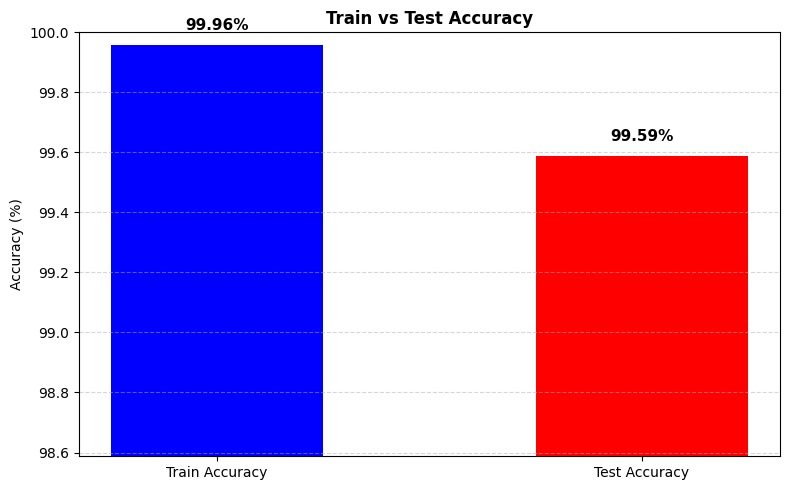

In [ ]:
plt.figure(figsize=(8, 5))

labels = ['Train Accuracy', 'Test Accuracy']
values = [train_acc * 100, test_acc * 100]
colors = ['blue', 'red']

bars = plt.bar(labels, values, color=colors, width=0.5)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
              f"{val:.2f}%", ha='center', fontsize=11, fontweight='bold')

plt.title('Train vs Test Accuracy', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(min(values) - 1, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

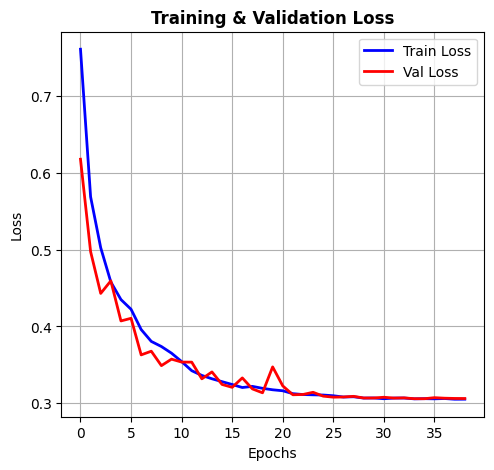

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Val Loss', color='red', linewidth=2)
plt.title('Training & Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [ ]:
 #cm prediction
all_preds = []
all_labels = []
model.eval()

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.numpy())


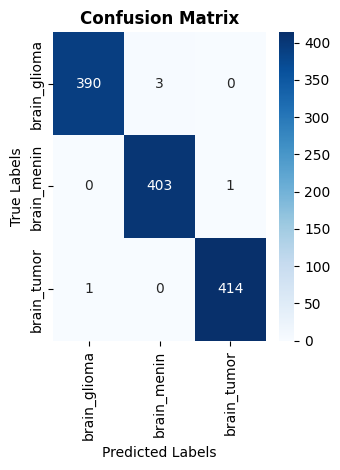

In [ ]:
cm = confusion_matrix(all_labels, all_preds)


plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.tight_layout()
plt.show()

In [ ]:
 #calssification report
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=categories))

# log the full classification report as an MLflow artifact
report_text = classification_report(all_labels, all_preds, target_names=categories)
with open("classification_report.txt", "w") as f:
    f.write(report_text)
mlflow.log_artifact("classification_report.txt")

# log the trained model itself to MLflow's model registry format
mlflow.pytorch.log_model(
    model,
    name="model",
    serialization_format="pickle"
)

mlflow.end_run()
print("MLflow run logged. Launch the UI with: mlflow ui --backend-store-uri ./mlruns")


              precision    recall  f1-score   support

brain_glioma       1.00      0.99      0.99       393
 brain_menin       0.99      1.00      1.00       404
 brain_tumor       1.00      1.00      1.00       415

    accuracy                           1.00      1212
   macro avg       1.00      1.00      1.00      1212
weighted avg       1.00      1.00      1.00      1212



2026/07/21 16:47:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/21 16:47:39 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/21 16:47:50 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version la

MLflow run logged. Launch the UI with: mlflow ui --backend-store-uri ./mlruns



--- Statistical Analysis (P-Value Calculation) ---
Total Test Samples: 1212
Correct Predictions (True Positives): 1207
Incorrect Predictions (Errors): 5

[Chi-Square Test vs Random Guess Baseline]
Chi-Square Statistic: 2394.0928
Calculated P-Value: 0.0
Result: Statistically SIGNIFICANT (P < 0.05). The model's feature learning is highly reliable.

Visualizing predictions on random test samples...


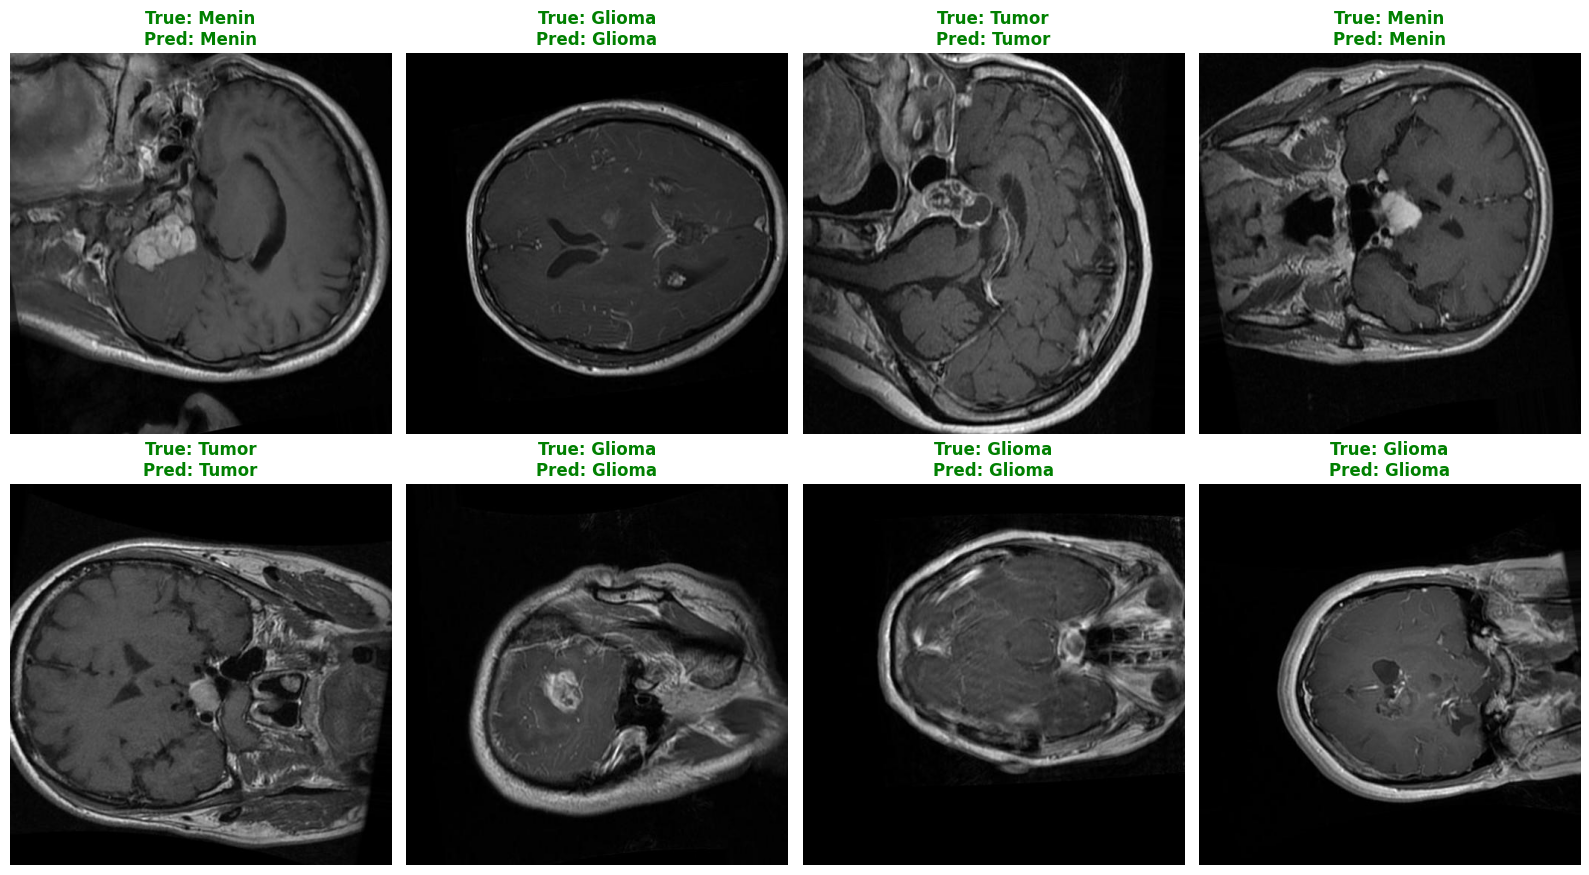

In [ ]:
from scipy.stats import chisquare
print("\n--- Statistical Analysis (P-Value Calculation) ---")
true_labels_arr = np.array(all_labels)
pred_labels_arr = np.array(all_preds)

total_samples = len(true_labels_arr)
total_correct = np.sum(true_labels_arr == pred_labels_arr)
total_incorrect = total_samples - total_correct

print(f"Total Test Samples: {total_samples}")
print(f"Correct Predictions (True Positives): {total_correct}")
print(f"Incorrect Predictions (Errors): {total_incorrect}")

# Testing against a random baseline classifier (33.33% chance for 3 classes)
expected_correct = total_samples / 3.0
expected_incorrect = total_samples * (2.0 / 3.0)

chi2_stat, p_value_chi2 = chisquare(f_obs=[total_correct, total_incorrect], f_exp=[expected_correct, expected_incorrect])

print(f"\n[Chi-Square Test vs Random Guess Baseline]")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"Calculated P-Value: {p_value_chi2}")

if p_value_chi2 < 0.05:
    print("Result: Statistically SIGNIFICANT (P < 0.05). The model's feature learning is highly reliable.")
else:
    print("Result: NOT Statistically Significant. The performance could be due to random chance.")
#visualizing random sample
print("\nVisualizing predictions on random test samples...")
random_indices = random.sample(range(len(test_dataset_full)), 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    raw_img, true_label_idx = test_dataset_full[idx]
    transformed_img, _ = test_dataset[idx]

    with torch.no_grad():
        outputs = model(transformed_img.unsqueeze(0).to(device))
        _, pred_label_idx = torch.max(outputs, 1)

    true_name = categories[true_label_idx].split('_')[1].capitalize()
    pred_name = categories[pred_label_idx.item()].split('_')[1].capitalize()
    color = 'green' if true_label_idx == pred_label_idx.item() else 'red'

    axes[i].imshow(raw_img)
    axes[i].axis('off')
    axes[i].set_title(f"True: {true_name}\nPred: {pred_name}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()